In [ ]:
import os
os.chdir(Insert Project Path)

### Notebook 5: Risk score
Recall, I defined my *risk score* as an event-level score designed to represent the combination of characteristics associated with greater asteroid close-approach risk. The aim was not to replicate NASA's classfication of a hazardous event. This score would be a weighted sum of the velocity component, size component, and distance component. I wanted research to inform the size of the contribution each component would have.

In [17]:
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from src.scoring import calculate_size_score, calculate_distance_score, calculate_velocity_score, calculate_risk_score

In [18]:
#loading SQL into pandas df
with sqlite3.connect("data/nasa_asteroids.db") as c:

    df = pd.read_sql_query("""
        SELECT *
        FROM close_approaches
        """, c
    )

#converting dates again
df["close_approach_date"] = pd.to_datetime(
    df["close_approach_date"]
)

df["close_approach_date_full"] = pd.to_datetime(
    df["close_approach_date_full"],
    format="mixed"
)

In [19]:
#passing functions to calculate components
df["size_score"] = calculate_size_score(df["diameter_min_km"], df["diameter_max_km"])
df["velocity_score"] = calculate_velocity_score(df["relative_velocity_km_s"])
df["distance_score"] = calculate_distance_score(df["miss_distance_au"])

In [20]:
df[["size_score","velocity_score","distance_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
size_score,14471.0,0.499478,0.213337,0.037433,0.320768,0.488589,0.686067,0.991507
velocity_score,14471.0,0.065892,0.066975,0.000002,0.019236,0.046285,0.090291,0.919900
distance_score,14471.0,0.473334,0.280902,0.000097,0.226420,0.472492,0.709879,0.999790


Notice that the velocity score had a much lower mean and median than the other two (0.066 vs 0.500 and 0.473). But, this did also align with my research. Velocity is a secondary factor behind size and distance when attributing risk to a close approach event. Its contribution should be small unless the asteroid is travelling at a high velocity.

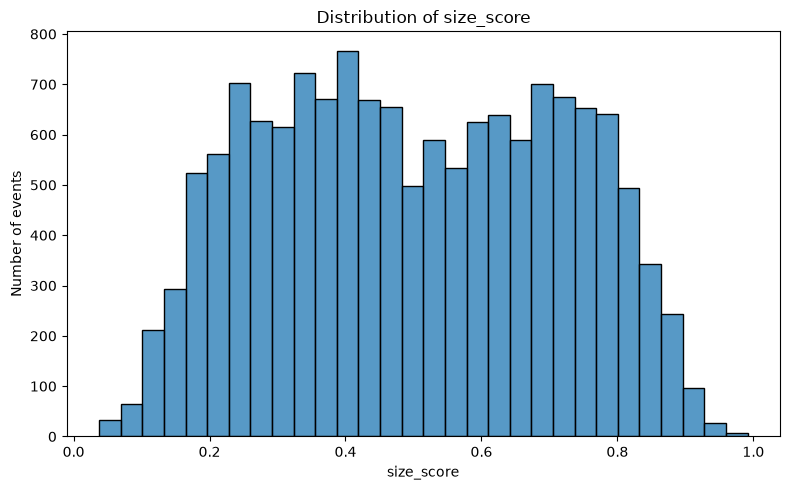

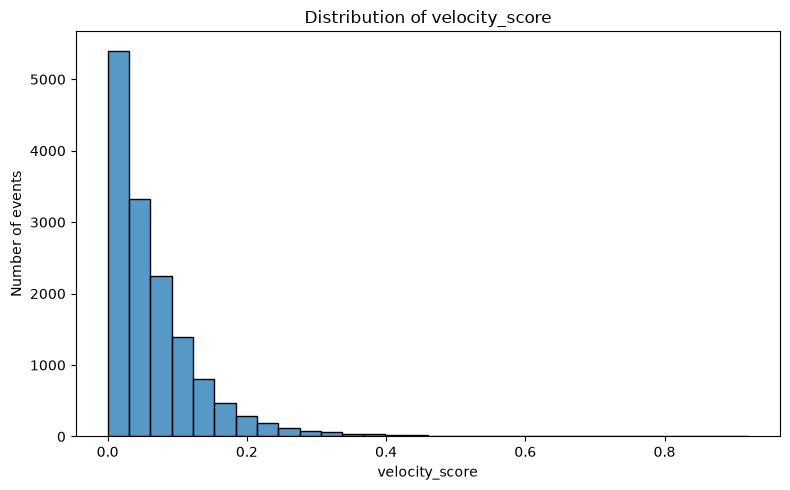

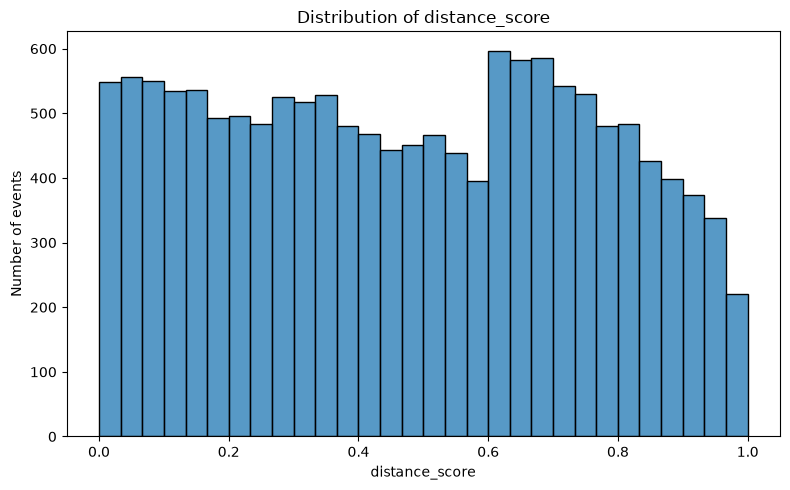

In [ ]:
score_features = [
    "size_score",
    "velocity_score",
    "distance_score"
]

for feature in score_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(data=df, x=feature, bins=30)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of events")

    plt.show()

Again, we can justify velocitys right skew, as we only want velocity to be impactful if it is travelling at a high velocity. According to NASA, and the median of the relative velocity data, most near-Earth objects have velocities of around 20 km/s and shouldn't be considered hazardous. The quadratic scoring reflects the actual impact of velocity on the risk of the event.

Now, I wanted to decide upon weighting.

According to NASA, size is the primary destructive factor an asteroid, whilst distance from Earth determines how likely the collision is to occur. Velocity is considered a secondary destructive factor. Based of this, I believed the weights  for size / distance / velocity should be 0.4 / 0.3 / 0.3 respectively.

In [22]:
size_weight = 0.4
velocity_weight = 0.3
distance_weight = 0.3

df["risk_score"] = (size_weight * df["size_score"]) + (velocity_weight * df["velocity_score"]) + (distance_weight * df["distance_score"])

In [23]:
df[
    [
        "name",
        "relative_velocity_km_s",
        "velocity_score",
        "size_score",
        "distance_score",
        "risk_score"
    ]
].sort_values(
    "risk_score",
    ascending=False
).head(20)

,name,relative_velocity_km_s,velocity_score,size_score,distance_score,risk_score
3361,231937 (2001 FO32),34.413166,0.328963,0.899437,0.973043,0.750376
12005,66008 (1998 QH2),34.079764,0.322620,0.940581,0.844739,0.726440
11979,465402 (2008 HW1),38.781382,0.417777,0.903291,0.784557,0.722017
10720,415029 (2011 UL21),25.882225,0.186080,0.940581,0.911212,0.705420
13518,276033 (2002 AJ129),37.703531,0.394877,0.850601,0.813332,0.702703
4769,(2019 RU3),31.081353,0.268347,0.884486,0.893167,0.702249
10669,504034 (2005 UJ159),31.814543,0.281157,0.897791,0.853810,0.699607
5257,7482 (1994 PC1),19.555465,0.106227,0.926014,0.973509,0.694327
572,137924 (2000 BD19),34.579482,0.332150,0.900089,0.771575,0.691153
4281,(2016 AJ193),26.169018,0.190227,0.866389,0.954179,0.689877


From this, one can observe that the events with the highest risk score are dominated by events with high size and distance scores  - this is correct. An event with a high velocity score shouldn't be classified as high risk if it is nowhere near the Earth, for example.

Finally, I implemented the function for calculating the risk score into *scoring.py*.

In [25]:
df["risk_score"] = calculate_risk_score(calculate_size_score(df["diameter_min_km"], df["diameter_max_km"]), calculate_velocity_score(df["relative_velocity_km_s"]), calculate_distance_score(df["miss_distance_au"]))


In [26]:
#investigating, and validating the scoring
print(df["risk_score"].min(), df["risk_score"].max())
df["risk_score"].describe()

0.04435099486882415 0.7503763162981776


count    14471.000000
mean         0.361559
std          0.121680
min          0.044351
25%          0.270812
50%          0.360234
75%          0.447371
max          0.750376
Name: risk_score, dtype: float64

I believe the scoring reflects the distribution well, over 75% asteroids have a risk score below 0.5, and the highest risk score between 2020-01-01 and 2026-08-31 is 0.750, leaving room for asteroids attributed with higher risk in the future.

In [27]:
#presenting the top 20 close approach events by risk score between 01/01/2020 and 31/08/2026
df.sort_values("risk_score", ascending=False).head(20)

,event_id,asteroid_id,name,absolute_magnitude_h,diameter_min_km,diameter_max_km,is_potentially_hazardous,is_sentry_object,close_approach_date,close_approach_date_full,relative_velocity_km_s,miss_distance_au,orbiting_body,size_score,velocity_score,distance_score,risk_score
3361,2231937_2021-Mar-21 16:03,2231937,231937 (2001 FO32),17.51,0.836672,1.870854,1,0,2021-03-21,2021-03-21 16:03:00,34.413166,0.013479,Earth,0.899437,0.328963,0.973043,0.750376
12005,2066008_2025-Mar-09 22:19,2066008,66008 (1998 QH2),15.93,1.732028,3.872933,0,0,2025-03-09,2025-03-09 22:19:00,34.079764,0.077631,Earth,0.940581,0.322620,0.844739,0.726440
11979,2465402_2025-Mar-03 16:12,2465402,465402 (2008 HW1),17.39,0.884209,1.977152,0,0,2025-03-03,2025-03-03 16:12:00,38.781382,0.107721,Earth,0.903291,0.417777,0.784557,0.722017
10720,2415029_2024-Jun-27 20:16,2415029,415029 (2011 UL21),15.93,1.732028,3.872933,1,0,2024-06-27,2024-06-27 20:16:00,25.882225,0.044394,Earth,0.940581,0.186080,0.911212,0.705420
13518,2276033_2026-Feb-09 18:09,2276033,276033 (2002 AJ129),18.76,0.470495,1.052059,1,0,2026-02-09,2026-02-09 18:09:00,37.703531,0.093334,Earth,0.850601,0.394877,0.813332,0.702703
4769,3843858_2021-Oct-29 02:37,3843858,(2019 RU3),17.94,0.686365,1.534758,1,0,2021-10-29,2021-10-29 02:37:00,31.081353,0.053416,Earth,0.884486,0.268347,0.893167,0.702249
10669,2504034_2024-Jun-16 20:55,2504034,504034 (2005 UJ159),17.56,0.817627,1.828269,1,0,2024-06-16,2024-06-16 20:55:00,31.814543,0.073095,Earth,0.897791,0.281157,0.853810,0.699607
5257,2007482_2022-Jan-18 21:51,2007482,7482 (1994 PC1),16.58,1.283970,2.871045,1,0,2022-01-18,2022-01-18 21:51:00,19.555465,0.013245,Earth,0.926014,0.106227,0.973509,0.694327
572,2137924_2020-Feb-09 23:05,2137924,137924 (2000 BD19),17.49,0.844413,1.888165,0,0,2020-02-09,2020-02-09 23:05:00,34.579482,0.114213,Earth,0.900089,0.332150,0.771575,0.691153
4281,3740498_2021-Aug-21 15:10,3740498,(2016 AJ193),18.40,0.555335,1.241767,1,0,2021-08-21,2021-08-21 15:10:00,26.169018,0.022911,Earth,0.866389,0.190227,0.954179,0.689877


Above, are the top 20 close approach events according to my risk scoring. Comparing this to NASA's classification of a potentially hazardous object is interesting, as we can observe that there is a substantial overlap between a high risk score and this attribute. However, it can also be seen that none of these asteroids are monitored by NASA's Sentry system. This motivates me to continue the project by using unsupervised learning to detect anomalies, as perhaps anomalous events are more important to NASA than the classification of "risk" that I defined.